In [11]:
import statsmodels.api as sm

In [12]:
import numpy as np
import pandas as pd

In [13]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

In [57]:
df = pd.read_csv('bitcoin.csv')
tdf = df.tail(1000)
tdf.columns = [col.lower() for col in tdf.columns]

In [58]:
tdf.head()


,date,open,high,low,close,volume
35168,2021-08-26 16:00:00,46800.00,47056.86,46485.16,46897.72,2263.61921
35169,2021-08-26 17:00:00,46897.72,47123.65,46886.01,46950.26,1276.36545
35170,2021-08-26 18:00:00,46950.26,47092.63,46731.00,47001.46,1128.54621
35171,2021-08-26 19:00:00,47001.47,47043.88,46755.27,46939.75,1212.66545
35172,2021-08-26 20:00:00,46934.22,47058.23,46845.00,47017.57,949.73043


In [18]:
type(tdf.index)

pandas.core.indexes.range.RangeIndex

In [19]:
mod = sm.QuantReg(tdf['close'], tdf.index)

In [20]:
result = mod.fit(q=0.75)

In [21]:
print(result.summary())

                         QuantReg Regression Results                          
Dep. Variable:                  close   Pseudo R-squared:             -0.04682
Model:                       QuantReg   Bandwidth:                       1283.
Method:                 Least Squares   Sparsity:                        9748.
Date:                Sun, 06 Oct 2024   No. Observations:                 1000
Time:                        12:30:20   Df Residuals:                      999
                                        Df Model:                            1
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1             1.3690      0.004    366.002      0.000       1.362       1.376


In [22]:
close_pred = result.predict(tdf.index)

In [23]:
close_pred

array([48146.10510302, 48147.47413467, 48148.84316632, 48150.21219797,
       48151.58122962, 48152.95026127, 48154.31929293, 48155.68832458,
       48157.05735623, 48158.42638788, 48159.79541953, 48161.16445118,
       48162.53348283, 48163.90251448, 48165.27154613, 48166.64057779,
       48168.00960944, 48169.37864109, 48170.74767274, 48172.11670439,
       48173.48573604, 48174.85476769, 48176.22379934, 48177.59283099,
       48178.96186264, 48180.3308943 , 48181.69992595, 48183.0689576 ,
       48184.43798925, 48185.8070209 , 48187.17605255, 48188.5450842 ,
       48189.91411585, 48191.2831475 , 48192.65217915, 48194.02121081,
       48195.39024246, 48196.75927411, 48198.12830576, 48199.49733741,
       48200.86636906, 48202.23540071, 48203.60443236, 48204.97346401,
       48206.34249566, 48207.71152732, 48209.08055897, 48210.44959062,
       48211.81862227, 48213.18765392, 48214.55668557, 48215.92571722,
       48217.29474887, 48218.66378052, 48220.03281217, 48221.40184383,
      

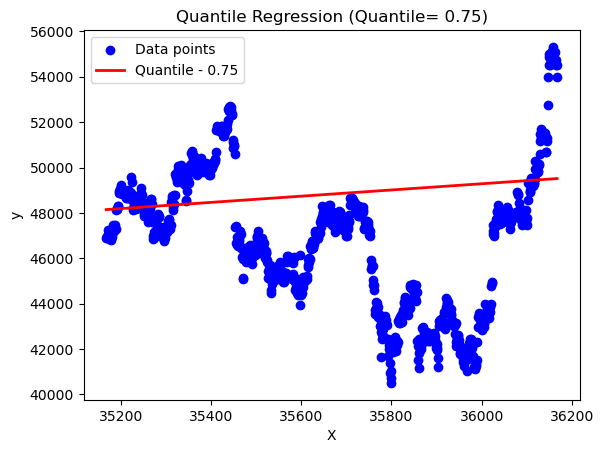

In [26]:
# Plot the original data points and the quantile regression line
plt.scatter(tdf.index, tdf['close'], color="blue", label="Data points")
plt.plot(tdf.index, close_pred, color="red", label="Quantile - 0.75", linewidth=2)

plt.xlabel("X")
plt.ylabel("y")
plt.title("Quantile Regression (Quantile= 0.75)")
plt.legend()
plt.show()

In [33]:
np.arange(10)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [71]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

def get_quantile_reg(dataframe: pd.DataFrame, timeperiod= 55):
    # Callback function for quantile regression
    df = dataframe.copy()
    def quantile_regression(window_data, quantile):
        p = window_data
        t = np.arange(len(p))
        t = sm.add_constant(t)  # Add constant for intercept

        # Fit the quantile regression model
        model = sm.QuantReg(p, t)
        result = model.fit(q=quantile)
        
        # Predict the last value in the rolling window
        # t_last = np.array([1, len(y) - 1]).reshape(1, -1)  # [constant, last index]
        return result.predict(t[-1:])  # Return predicted value for the last point
    
    # Apply quantile regression for 0.75 and 0.25 quantiles using rolling().apply()
    df['q_upper'] = df['Close'].rolling(window=timeperiod).apply(
        lambda x: quantile_regression(x, 0.75), raw=True
    )
    
    df['q_lower'] = df['Close'].rolling(window=timeperiod).apply(
        lambda x: quantile_regression(x, 0.25), raw=True
    )
    
    # Return the DataFrame with both quantile columns
    return df[['q_upper', 'q_lower']]

# # Example usage:
# # Assuming df is your OHLCV DataFrame with a 'Close' column
# np.random.seed(42)
# n = 100
# close_prices = 100 + np.cumsum(np.random.randn(n))  # Simulate some close prices
# df = pd.DataFrame({'Close': close_prices})

# # Call the function
# quantile_results = get_quantile_reg(df, timeperiod=55)

# # Display the result
# print(quantile_results)


In [72]:
tdf[['upper', 'lower']] = get_quantile_reg(tdf)

c:\Users\xlfin\anaconda3\lib\site-packages\statsmodels\regression\quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
c:\Users\xlfin\anaconda3\lib\site-packages\statsmodels\regression\quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
c:\Users\xlfin\anaconda3\lib\site-packages\statsmodels\regression\quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
c:\Users\xlfin\anaconda3\lib\site-packages\statsmodels\regression\quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
c:\Users\xlfin\anaconda3\lib\site-packages\statsmodels\regression\quantile_regressio

In [73]:
tdf.tail(100)

,Date,Open,High,Low,Close,Volume,upper,lower
36068,2021-10-03 06:00:00,47990.13,48057.00,47896.93,47972.99,617.25174,48135.025543,47598.328423
36069,2021-10-03 07:00:00,47970.15,47970.16,47814.00,47895.99,569.31948,48006.505218,47594.457079
36070,2021-10-03 08:00:00,47896.00,47983.38,47798.50,47823.99,838.17079,47988.106670,47823.989999
36071,2021-10-03 09:00:00,47823.98,47869.00,47600.00,47830.09,1489.72226,47966.197169,47829.014348
36072,2021-10-03 10:00:00,47830.09,47953.20,47730.00,47812.32,625.24084,47963.932854,47812.320001
...,...,...,...,...,...,...,...,...
36163,2021-10-07 05:00:00,55073.20,55073.21,54545.07,54735.76,2251.12202,56153.739995,55245.733810
36164,2021-10-07 06:00:00,54735.77,54968.06,54375.83,54534.16,1783.00426,56171.076672,55455.161765
36165,2021-10-07 07:00:00,54534.16,54793.26,54235.33,54755.92,4163.43136,55869.580001,55112.118969
36166,2021-10-07 08:00:00,54755.91,54778.91,54400.00,54538.30,2049.38218,55232.880001,55300.298386


In [74]:
tdf.index = tdf.Date

In [75]:
tdf.head()

,Date,Open,High,Low,Close,Volume,upper,lower
Date,,,,,,,,
2021-08-26 16:00:00,2021-08-26 16:00:00,46800.00,47056.86,46485.16,46897.72,2263.61921,NaN,NaN
2021-08-26 17:00:00,2021-08-26 17:00:00,46897.72,47123.65,46886.01,46950.26,1276.36545,NaN,NaN
2021-08-26 18:00:00,2021-08-26 18:00:00,46950.26,47092.63,46731.00,47001.46,1128.54621,NaN,NaN
2021-08-26 19:00:00,2021-08-26 19:00:00,47001.47,47043.88,46755.27,46939.75,1212.66545,NaN,NaN
2021-08-26 20:00:00,2021-08-26 20:00:00,46934.22,47058.23,46845.00,47017.57,949.73043,NaN,NaN


In [76]:
tdf

,Date,Open,High,Low,Close,Volume,upper,lower
Date,,,,,,,,
2021-08-26 16:00:00,2021-08-26 16:00:00,46800.00,47056.86,46485.16,46897.72,2263.61921,NaN,NaN
2021-08-26 17:00:00,2021-08-26 17:00:00,46897.72,47123.65,46886.01,46950.26,1276.36545,NaN,NaN
2021-08-26 18:00:00,2021-08-26 18:00:00,46950.26,47092.63,46731.00,47001.46,1128.54621,NaN,NaN
2021-08-26 19:00:00,2021-08-26 19:00:00,47001.47,47043.88,46755.27,46939.75,1212.66545,NaN,NaN
2021-08-26 20:00:00,2021-08-26 20:00:00,46934.22,47058.23,46845.00,47017.57,949.73043,NaN,NaN
...,...,...,...,...,...,...,...,...
2021-10-07 05:00:00,2021-10-07 05:00:00,55073.20,55073.21,54545.07,54735.76,2251.12202,56153.739995,55245.733810
2021-10-07 06:00:00,2021-10-07 06:00:00,54735.77,54968.06,54375.83,54534.16,1783.00426,56171.076672,55455.161765
2021-10-07 07:00:00,2021-10-07 07:00:00,54534.16,54793.26,54235.33,54755.92,4163.43136,55869.580001,55112.118969


In [82]:
otdf = tdf

In [83]:
tdf = tdf.tail(200)

In [85]:
# 假设您的 DataFrame 名为 df，并且包含 'Open', 'High', 'Low', 'Close', 'quantile_.75', 'quantile_.25' 列
# 转换索引为日期时间格式（如果尚未这样做）
tdf['Date'] = pd.to_datetime(tdf.index)

# 创建 OHLC 图表
fig = go.Figure(data=[
    go.Ohlc(
        x=tdf['Date'],
        open=tdf['Open'],
        high=tdf['High'],
        low=tdf['Low'],
        close=tdf['Close'],
        name='OHLC'
    ),
    go.Scatter(
        x=tdf['Date'],
        y=tdf['upper'],
        fill='tonexty',
        fillcolor='rgba(0,100,80,0.2)',
        line=dict(color='rgba(0,100,80,0.5)'),
        name='75% Quantile'
    ),
    go.Scatter(
        x=tdf['Date'],
        y=tdf['lower'],
        fill='tonexty',
        fillcolor='rgba(0,176,240,0.2)',
        line=dict(color='rgba(0,176,240,0.5)'),
        name='25% Quantile'
    )
])

# 更新图表布局
fig.update_layout(
    title='OHLCV and Quantile Regression',
    xaxis_title='Date',
    yaxis_title='Price',
    legend_title='Legend'
)

# 显示图表
fig.show()

C:\Users\xlfin\AppData\Local\Temp\ipykernel_28840\4245243914.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

